**20250910 Time Series Analysis - US Work From Home Data**

The FRED recently added US work from home data to its API system.  Let's see what types of trend can be observed.

https://news.research.stlouisfed.org/2025/08/fred-adds-new-work-from-home-data/

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from pandas_datareader import data as pdr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.svm import SVR

In [2]:
# Input FRED API key here
# fred_key ="Your FRED API Key here"
fred_key =""
fred = Fred(fred_key)

Each time series earliest data point reached from 2019 to 2022.

- Work from Home Rate (WFHCOVIDMATQUESTION)
- All Full-Time Wage and Salary Workers: Working Fully Remote (FULLREMOTECURR)
- All Full-Time Wage and Salary Workers: Working in Hybrid (Some Days Working from Home, Some Days at Employer or Client Site) (HYBRIDCURR)
- Work from Home Rate: Men (WFHCOVIDFRACMATMEN)
- Work from Home Rate: Women (WFHCOVIDFRACMATWOMEN)

In [3]:
start_date = "2019-01-01"
#end_date = '2023-12-31'

In [4]:
fred_series_id_01 = ["WFHCOVIDMATQUESTION",
                     "FULLREMOTECURR",
                     "HYBRIDCURR",
                     "WFHCOVIDFRACMATMEN",
                     "WFHCOVIDFRACMATWOMEN"]
df_fred_data_01 = pdr.DataReader(fred_series_id_01, 'fred', start=start_date) #end=end_date)
df_fred_data_01

,WFHCOVIDMATQUESTION,FULLREMOTECURR,HYBRIDCURR,WFHCOVIDFRACMATMEN,WFHCOVIDFRACMATWOMEN
DATE,,,,,
2019-12-01,7.15,NaN,NaN,NaN,NaN
2020-01-01,NaN,NaN,NaN,NaN,NaN
2020-02-01,NaN,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN,NaN
2020-04-01,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-04-01,27.55,12.16,27.73,26.573460,28.865250
2025-05-01,27.18,12.53,26.76,27.085571,27.523108
2025-06-01,27.89,11.60,27.00,26.593847,29.672398


In [5]:
df_fred_data_01 = df_fred_data_01.dropna()
df_fred_data_01

,WFHCOVIDMATQUESTION,FULLREMOTECURR,HYBRIDCURR,WFHCOVIDFRACMATMEN,WFHCOVIDFRACMATWOMEN
DATE,,,,,
2021-11-01,33.17,15.26,30.37,34.465088,30.933208
2021-12-01,33.35,13.99,32.56,32.637463,34.270451
2022-01-01,32.50,17.75,25.45,31.015499,34.630417
2022-02-01,31.13,17.73,22.78,29.821871,32.433708
2022-03-01,31.08,15.47,27.25,30.465982,31.975880
2022-04-01,29.58,12.97,27.84,29.232807,30.093311
2022-05-01,31.57,13.71,30.75,32.540791,30.652590
2022-06-01,31.65,13.57,33.46,33.084057,30.492603
2022-07-01,30.72,14.20,28.48,30.170959,31.452030


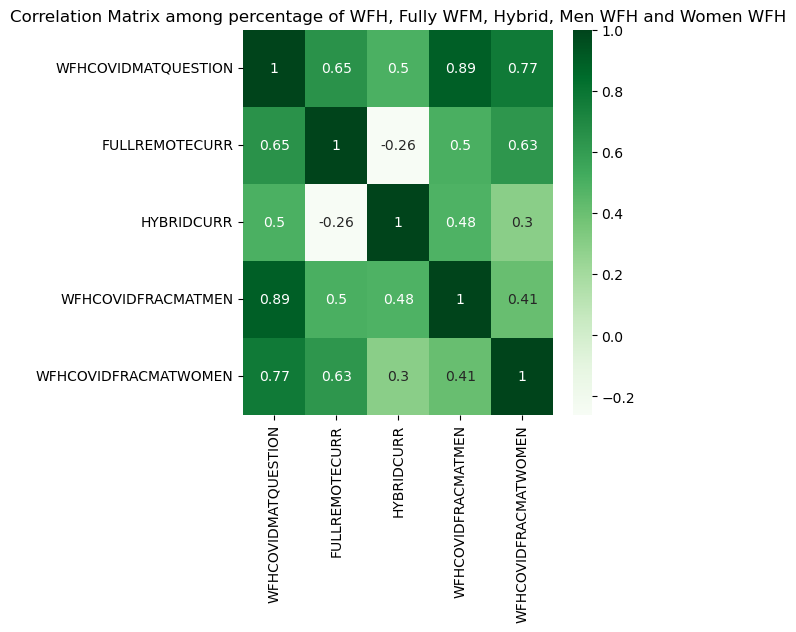

In [6]:
plt.figure(figsize = (5,5))
ax = plt.axes()
sns.heatmap(df_fred_data_01.corr(), cmap="Greens", annot=True, ax = ax)
ax.set_title('Correlation Matrix among percentage of WFH, Fully WFM, Hybrid, Men WFH and Women WFH')
plt.show()

The overall Work From Home rate seems to be more correlate with Men's WFH rate than Women's

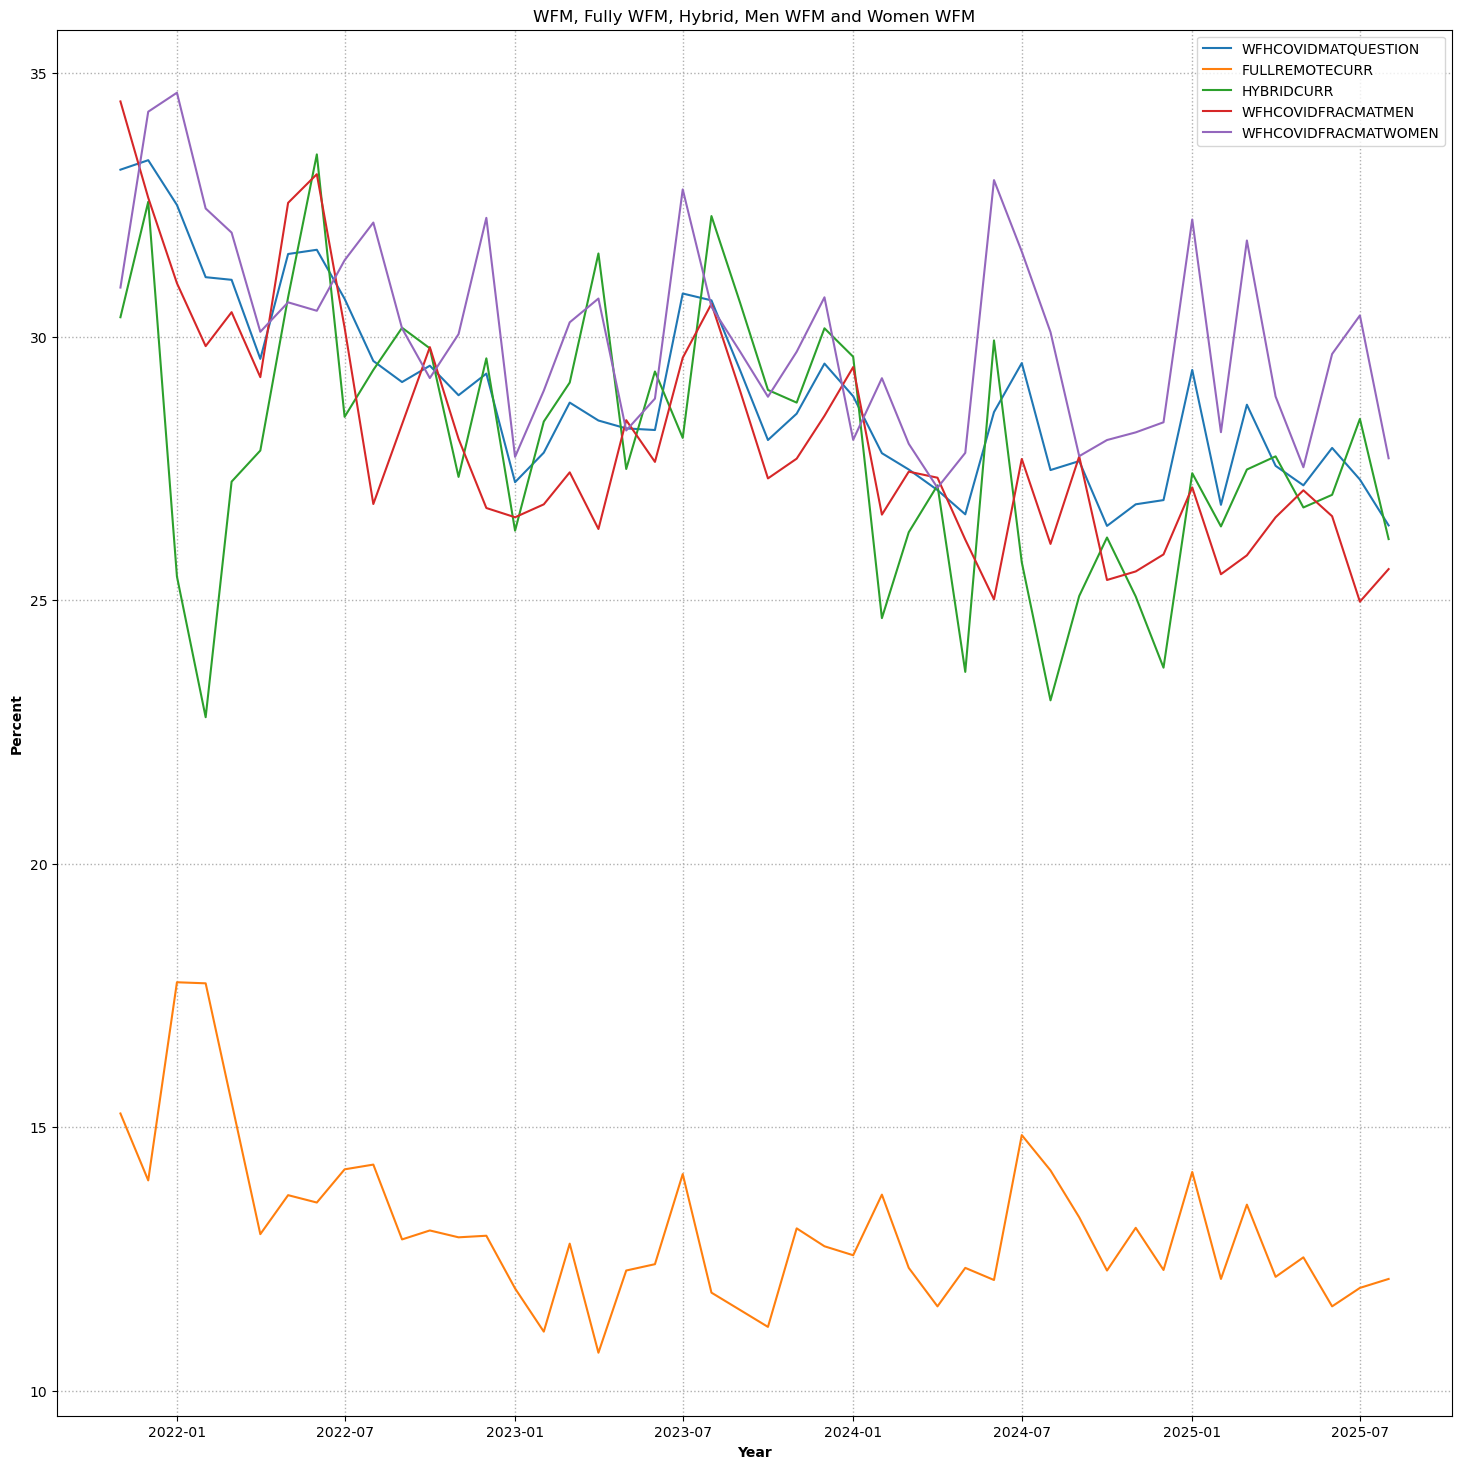

In [7]:
plt.figure(figsize = (18,18))
for i in range(len(df_fred_data_01.columns)):
    plt.plot(df_fred_data_01.index, df_fred_data_01.iloc[:,i].values, 
             label=df_fred_data_01.iloc[:,i].name)


plt.xlabel("Year", fontweight = 'bold')
plt.ylabel("Percent", fontweight = 'bold')
plt.title("WFM, Fully WFM, Hybrid, Men WFM and Women WFM")
plt.grid(True, ls=':', lw=1)
plt.legend()
plt.show()


The percentage of women WFH is generally harder than that of Men.  There have been months that Men's WFH rates are higher.

WFH Rate by sectors

- Work from Home Rate: Finance & Insurance, Wage and Salary Employees (WFHFRACMATFINANCEINSURANC)
- Work from Home Rate: Government, Wage and Salary Employees (WFHFRACMATGOVERNMENT)
- Work from Home Rate: Information, Wage and Salary Employees (WFHFRACMATINFORMATION)
- Work from Home Rate: Professional & Business Services, Wage and Salary Employees (WFHFRACMATPROFBUSSERVICES)
- Work from Home Rate: Hospitality & Food Services, Wage and Salary Employees (WFHFRACMATHOSPITAILITYFOO)
- Work from Home Rate: Transportation & Warehousing, Wage and Salary Employees (WFHFRACMATTRANSPWAREHOUSI)
- Work from Home Rate: Education, Wage and Salary Employees (WFHFRACMATEDUCATION)
- Work from Home Rate: Arts & Entertainment, Wage and Salary Employees (WFHFRACMATARTSENTERTAIN)
- Work from Home Rate: Retail Trade, Wage and Salary Employees (WFHFRACMATRETAIL)
- Work from Home Rate: Health Care & Social Assistance, Wage and Salary Employees (WFHFRACMATHEALTHCARE)
- Work from Home Rate: Manufacturing, Wage and Salary Employees (WFHFRACMATMANUFACTURING)
- Work from Home Rate: Utilities Wage and Salary Employees (WFHFRACMATUTILITIES)
- Work from Home Rate: Real Estate, Wage and Salary Employees (WFHFRACMATREALESTATE)
- Work from Home Rate: Wholesale Trade, Wage and Salary Employees (WFHFRACMATWHOLESALE)

**Comparing Men WFH rate against that of each sector**

In [8]:
fred_series_id_02M = ["WFHCOVIDFRACMATMEN",
                      "WFHFRACMATFINANCEINSURANC",
                      "WFHFRACMATGOVERNMENT",
                      "WFHFRACMATINFORMATION",
                      "WFHFRACMATPROFBUSSERVICES",
                      "WFHFRACMATHOSPITAILITYFOO",
                      "WFHFRACMATTRANSPWAREHOUSI",
                      "WFHFRACMATEDUCATION",
                      "WFHFRACMATARTSENTERTAIN",
                      "WFHFRACMATRETAIL",
                      "WFHFRACMATHEALTHCARE",
                      "WFHFRACMATMANUFACTURING",
                      "WFHFRACMATUTILITIES",
                      "WFHFRACMATREALESTATE",
                      "WFHFRACMATWHOLESALE"
                      
                     ]
df_fred_data_02M = pdr.DataReader(fred_series_id_02M, 'fred', start=start_date) #end=end_date)
df_fred_data_02M = df_fred_data_02M.dropna()
df_fred_data_02M 

,WFHCOVIDFRACMATMEN,WFHFRACMATFINANCEINSURANC,WFHFRACMATGOVERNMENT,WFHFRACMATINFORMATION,WFHFRACMATPROFBUSSERVICES,WFHFRACMATHOSPITAILITYFOO,WFHFRACMATTRANSPWAREHOUSI,WFHFRACMATEDUCATION,WFHFRACMATARTSENTERTAIN,WFHFRACMATRETAIL,WFHFRACMATHEALTHCARE,WFHFRACMATMANUFACTURING,WFHFRACMATUTILITIES,WFHFRACMATREALESTATE,WFHFRACMATWHOLESALE
DATE,,,,,,,,,,,,,,,
2022-01-01,31.015499,44.79,26.93,48.42,40.47,11.77,13.19,24.39,34.83,15.04,26.03,17.44,28.29,35.51,37.39
2023-01-01,26.574350,43.10,24.10,45.33,39.16,11.18,13.28,21.73,35.78,13.99,25.22,16.14,28.18,26.11,26.47
2024-01-01,29.423897,44.95,26.84,44.72,38.99,10.24,13.25,19.46,32.52,13.46,25.73,16.15,31.46,33.66,30.15
2025-01-01,27.140478,44.86,24.74,43.70,38.25,11.18,11.95,19.53,33.83,15.14,25.41,15.03,31.95,29.53,29.09


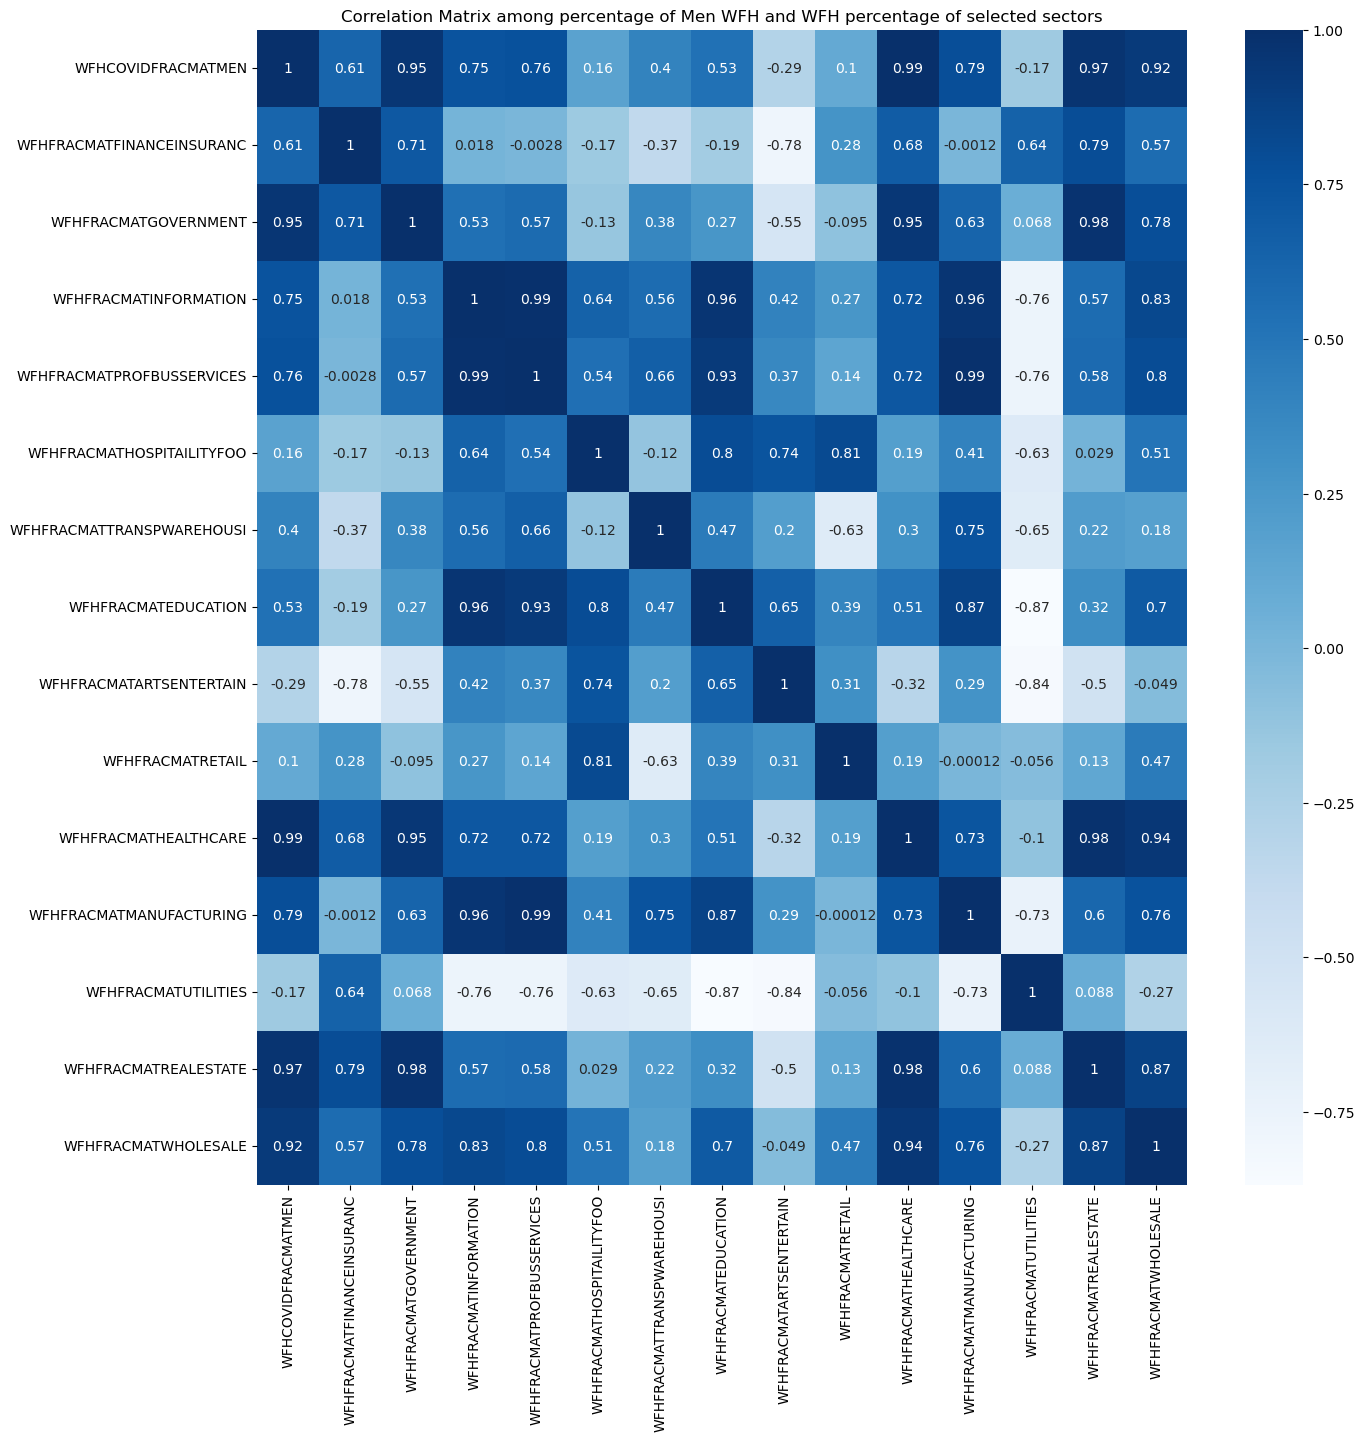

In [9]:
plt.figure(figsize = (15,15))
ax = plt.axes()
sns.heatmap(df_fred_data_02M.corr(), cmap="Blues", annot=True, ax = ax)
ax.set_title('Correlation Matrix among percentage of Men WFH and WFH percentage of selected sectors')
plt.show()

Men WFH rate is highly correlated with that in the Government, Healthcare, Real Estate, Wholesale sectors.

**Comparing Women WFH rate against that of each sector

In [10]:
fred_series_id_02F = ["WFHCOVIDFRACMATWOMEN",
                      "WFHFRACMATFINANCEINSURANC",
                      "WFHFRACMATGOVERNMENT",
                      "WFHFRACMATINFORMATION",
                      "WFHFRACMATPROFBUSSERVICES",
                      "WFHFRACMATHOSPITAILITYFOO",
                      "WFHFRACMATTRANSPWAREHOUSI",
                      "WFHFRACMATEDUCATION",
                      "WFHFRACMATARTSENTERTAIN",
                      "WFHFRACMATRETAIL",
                      "WFHFRACMATHEALTHCARE",
                      "WFHFRACMATMANUFACTURING",
                      "WFHFRACMATUTILITIES",
                      "WFHFRACMATREALESTATE",
                      "WFHFRACMATWHOLESALE"
                      
                     ]
df_fred_data_02F = pdr.DataReader(fred_series_id_02F, 'fred', start=start_date) #end=end_date)
df_fred_data_02F = df_fred_data_02F.dropna()
df_fred_data_02F 

,WFHCOVIDFRACMATWOMEN,WFHFRACMATFINANCEINSURANC,WFHFRACMATGOVERNMENT,WFHFRACMATINFORMATION,WFHFRACMATPROFBUSSERVICES,WFHFRACMATHOSPITAILITYFOO,WFHFRACMATTRANSPWAREHOUSI,WFHFRACMATEDUCATION,WFHFRACMATARTSENTERTAIN,WFHFRACMATRETAIL,WFHFRACMATHEALTHCARE,WFHFRACMATMANUFACTURING,WFHFRACMATUTILITIES,WFHFRACMATREALESTATE,WFHFRACMATWHOLESALE
DATE,,,,,,,,,,,,,,,
2022-01-01,34.630417,44.79,26.93,48.42,40.47,11.77,13.19,24.39,34.83,15.04,26.03,17.44,28.29,35.51,37.39
2023-01-01,27.720274,43.10,24.10,45.33,39.16,11.18,13.28,21.73,35.78,13.99,25.22,16.14,28.18,26.11,26.47
2024-01-01,28.043854,44.95,26.84,44.72,38.99,10.24,13.25,19.46,32.52,13.46,25.73,16.15,31.46,33.66,30.15
2025-01-01,32.224613,44.86,24.74,43.70,38.25,11.18,11.95,19.53,33.83,15.14,25.41,15.03,31.95,29.53,29.09


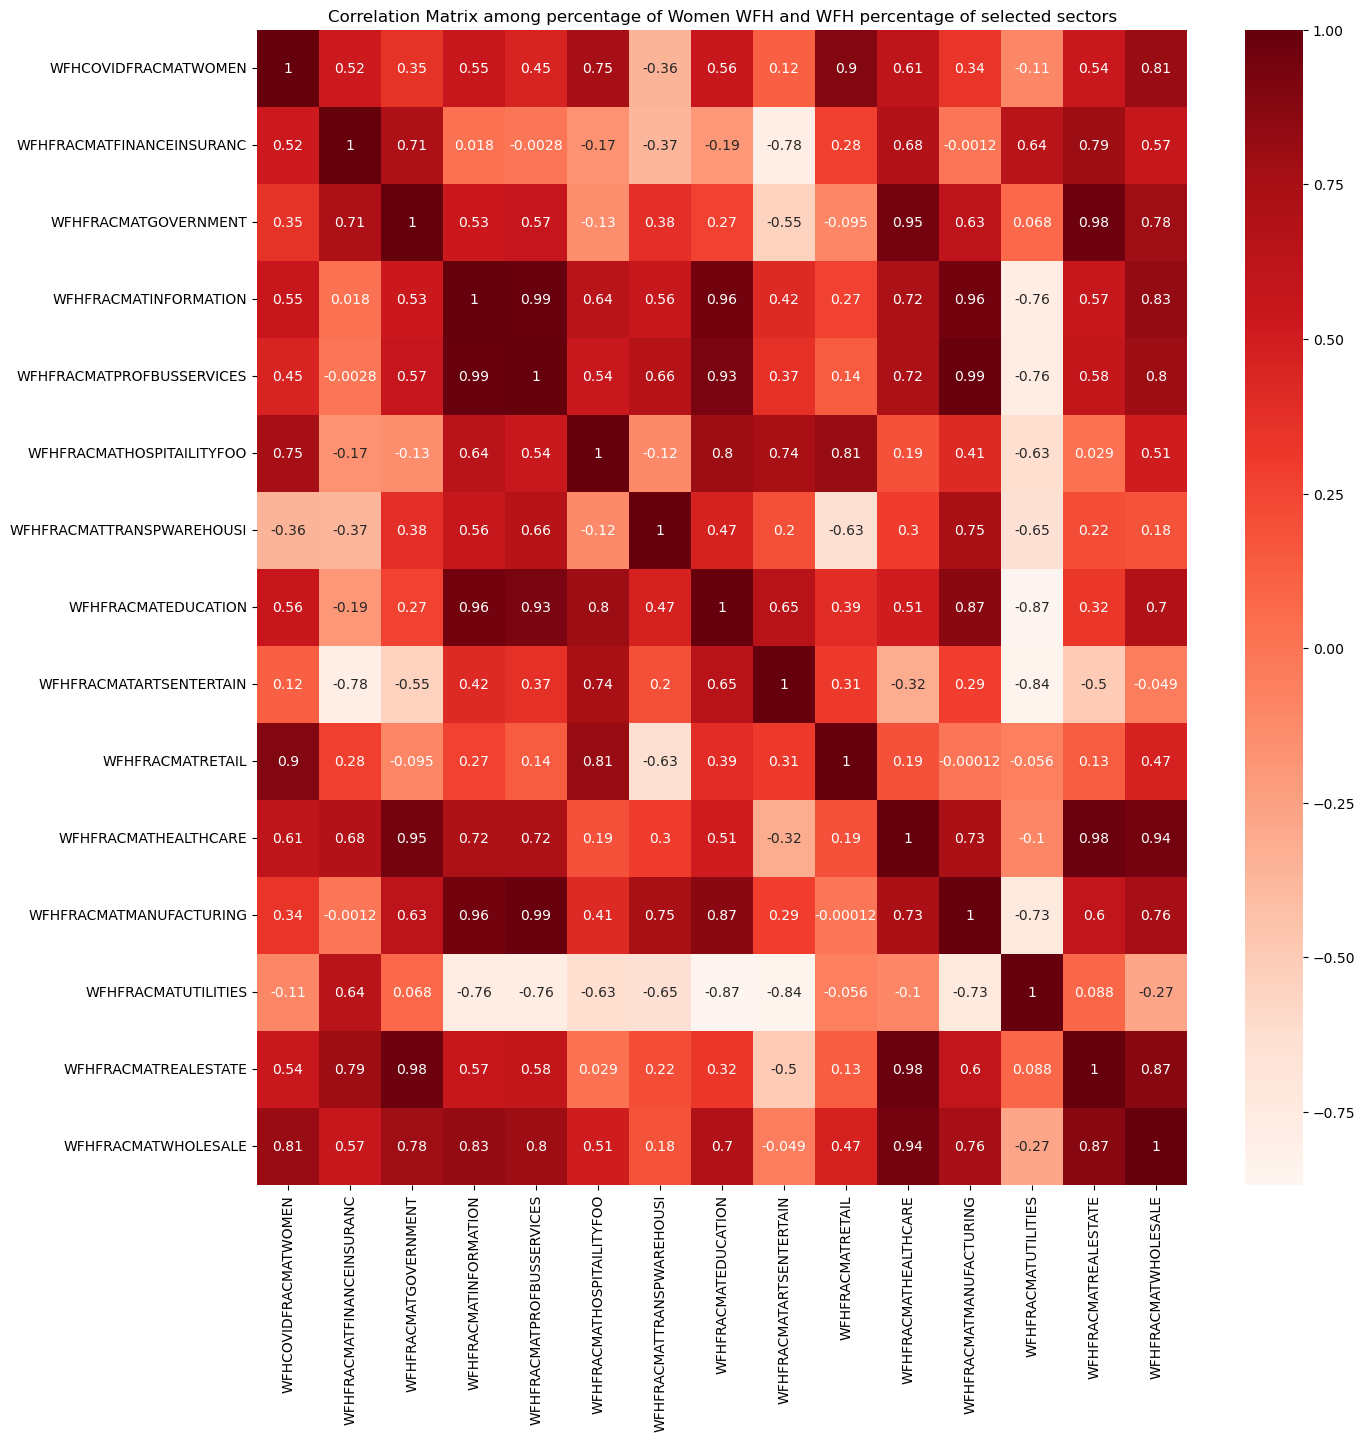

In [11]:
plt.figure(figsize = (15,15))
ax = plt.axes()
sns.heatmap(df_fred_data_02F.corr(), cmap="Reds", annot=True, ax = ax)
ax.set_title('Correlation Matrix among percentage of Women WFH and WFH percentage of selected sectors')
plt.show()

Women WFM rates do not show as much positive correlations as that of Men.   It is also highly correlated with Retail and Wholesale sectors.

**Difference in Correlations**

In [12]:
diff_corr_df = pd.DataFrame(data = df_fred_data_02M.corr().iloc[0, 1:] - df_fred_data_02F.corr().iloc[0, 1:], 
                            columns=["Values"])
diff_corr_df.sort_values(by="Values", ascending=False)

,Values
WFHFRACMATTRANSPWAREHOUSI,0.767624
WFHFRACMATGOVERNMENT,0.604213
WFHFRACMATMANUFACTURING,0.441944
WFHFRACMATREALESTATE,0.423399
WFHFRACMATHEALTHCARE,0.384366
WFHFRACMATPROFBUSSERVICES,0.310138
WFHFRACMATINFORMATION,0.193856
WFHFRACMATWHOLESALE,0.115502
WFHFRACMATFINANCEINSURANC,0.092102
WFHFRACMATEDUCATION,-0.025426


Transporatation and Warehousing sector has the largest differences.   Men WFH rate correlation is 0.4 but Women WFH rate is negatively correlated at 0.36.
WFH rate at government is 0.95 correlated with Men WFH rate while correlated with Women WFM at 0.35.

Retail is the opposite (0.9 with Women WFH, 0.1 with Male WFH).  Entertainment is also more correalted with Women WFH.

It seems that more traditional, blue-collar dependent sectors that have WFH rates more correlated to that of Men, while traditional, less manual labour focused sectors that are more related to Women WFH rate.  It is interesting to observed that the Government sector has such a high correlation with Men WFH rate.

More newly established and/or white collar focused sectors such as information and finance have much smaller difference in correlation.   Education and utilities are another two sectors that have very low difference as well.